# Install Dependecies

In [1]:
%%capture
%pip install numpy
%pip install pandas
%pip install matplotlib.pyplot
%pip install python-terrier
%pip install gensim
%pip install "pyterrier-alpha[parallel]"
%pip install ipynbname

In [2]:
# Load java
!curl -s "https://get.sdkman.io" | bash && source "$HOME/.sdkman/bin/sdkman-init.sh" && sdk install java 11.0.22-amzn < /dev/null

# check java and version
!which java
!java -version
!readlink -f $(which java)
!ls -la /usr/lib/jvm
!java --version
!javac --version


                                -+syyyyyyys:
                            `/yho:`       -yd.
                         `/yh/`             +m.
                       .oho.                 hy                          .`
                     .sh/`                   :N`                `-/o`  `+dyyo:.
                   .yh:`                     `M-          `-/osysoym  :hs` `-+sys:      hhyssssssssy+
                 .sh:`                       `N:          ms/-``  yy.yh-      -hy.    `.N-````````+N.
               `od/`                         `N-       -/oM-      ddd+`     `sd:     hNNm        -N:
              :do`                           .M.       dMMM-     `ms.      /d+`     `NMMs       `do
            .yy-                             :N`    ```mMMM.      -      -hy.       /MMM:       yh
          `+d+`           `:/oo/`       `-/osyh/ossssssdNMM`           .sh:         yMMN`      /m.
         -dh-           :ymNMMMMy  `-/shmNm-`:N/-.``   `.sN            /N-         `NMMy      .m/
  

# Imports

In [3]:
import itertools
import json
import os
import re
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pyterrier as pt
import gensim.downloader as api
from pathlib import Path
from tqdm.auto import tqdm
import pyterrier_alpha as pta
import ipynbname
from pyterrier.measures import nDCG, RR, P, R

In [4]:
ROOT_DIR = ipynbname.path().parent
ROOT_DIR = Path(ROOT_DIR)
print(ROOT_DIR)

/home/tlvj/msc_datalogi/2_semester/se/notebooks


# PyTerrier - Local

In [5]:
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["JVM_PATH"] = "/usr/lib/jvm/java-11-openjdk-amd64/lib/server/libjvm.so"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

import pyterrier as pt

if not pt.java.started():
    pt.java.init()

print("JAVA_HOME:", os.environ["JAVA_HOME"])
print("JVM_PATH:", os.environ["JVM_PATH"])
print("Java started:", pt.java.started())

JAVA_HOME: /usr/lib/jvm/java-11-openjdk-amd64
JVM_PATH: /usr/lib/jvm/java-11-openjdk-amd64/lib/server/libjvm.so
Java started: True


Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]


# Load Dataset

In [6]:
base = Path.cwd() / "msc_datalogi" / "2_semester" / "se" / "project_handout"
docs    = pd.read_json(f'{base}/docs2.jsonl', lines=True, dtype={'docno': str})
train_queries = pd.read_csv(f'{base}/train_queries.csv')
train_qrels   = pd.read_csv(f'{base}/train_qrels.csv')

# Load Indexes

In [7]:
index_path_none_obj = (ROOT_DIR / ".." / "indexes" / "full").resolve()
index_path_stop_obj = (ROOT_DIR / ".." / "indexes" / "stopwords").resolve()
index_path_stem_obj = (ROOT_DIR / ".." / "indexes" / "stemming").resolve()
index_path_stop_stem_obj = (ROOT_DIR / ".." / "indexes" / "stop-stem").resolve()

index_path_none = str(index_path_none_obj)
index_path_stop = str(index_path_stop_obj)
index_path_stem = str(index_path_stem_obj)
index_path_stop_stem = str(index_path_stop_stem_obj)

In [8]:
index_none = pt.IndexFactory.of(index_path_none)
index_stop = pt.IndexFactory.of(index_path_stop)
index_stem = pt.IndexFactory.of(index_path_stem)
index_stop_stem = pt.IndexFactory.of(index_path_stop_stem)

indices = {
    "stopwords": index_stop,
    "stop_stem": index_stop_stem,

    # Optional
    "none": index_none,
    "stem": index_stem
}

# Preprocessing

In [9]:
if "text" in train_queries.columns and "query" not in train_queries.columns:
    train_queries = train_queries.rename(columns={"text": "query"})

train_queries["qid"] = train_queries["qid"].astype(str)
train_queries["query"] = train_queries["query"].astype(str)

train_qrels["qid"] = train_qrels["qid"].astype(str)
train_qrels["docno"] = train_qrels["docno"].astype(str)

if "label" not in train_qrels.columns:
    if "relevance" in train_qrels.columns:
        train_qrels = train_qrels.rename(columns={"relevance": "label"})
    elif "rel" in train_qrels.columns:
        train_qrels = train_qrels.rename(columns={"rel": "label"})

train_qrels["label"] = train_qrels["label"].astype(int)

print("Training queries:")
display(train_queries.head())

print("Training qrels:")
display(train_qrels.head())

Training queries:


,qid,query
0,0,when did richmond last play in a preliminary f...
1,1,who sang what in the world's come over you
2,2,who produces the most wool in the world
3,3,where does alaska the last frontier take place
4,4,a day to remember all i want cameos


Training qrels:


,qid,docno,label,iteration
0,5743,D2,2,0
1,6266,D13,2,0
2,7918,D17,2,0
3,5215,D25,1,0
4,1173,D37,1,0


# Import tuning caches

In [10]:
cache_dir = (ROOT_DIR / ".." / "results").resolve()
cache_dir.mkdir(parents=True, exist_ok=True)

bm25_cache_path = cache_dir / "bm25_tuning_results.json"
lm_cache_path = cache_dir / "lm_tuning_results.json"
rm3_cache_path = cache_dir / "rm3_tuning_results.json"
rm3_lm_cache_path = cache_dir / "rm3_lm_tuning_results.json"
glove_cache_path = cache_dir / "glove_tuning_results.json"
baselines_cache_path = cache_dir / "baselines_results.json"

print(f"Using cache directory: {cache_dir}")

tuning_results = []

best_models = {
    index_name: {}
    for index_name in indices.keys()
}

Using cache directory: /home/tlvj/msc_datalogi/2_semester/se/results


### Import BM25

In [11]:
def load_bm25_cache():
    """Returns (tuning_results, best_configs) from the cache file.
    ([], {}) if the cache does not exist yet."""
    if not bm25_cache_path.exists():
        return [], {}
    with open(bm25_cache_path, "r") as f:
        cache = json.load(f)
    return cache["tuning_results"], cache["best_configs"]

In [14]:
def sync_bm25_state_from_cache():
    """Refresh shared state (`tuning_results`, `best_models`) from the cache file.
    Idempotent."""
    cached_rows, cached_best = load_bm25_cache()

    # Replace BM25 rows in the shared tuning_results list.
    tuning_results[:] = [r for r in tuning_results if r.get("model") != "BM25"]
    tuning_results.extend(cached_rows)

    # Rebuild best_models[<index>]["BM25"] from the cache.
    for index_name, best_info in cached_best.items():
        if index_name not in indices:
            continue
        index  = indices[index_name]
        config = best_info["config"]
        best_models[index_name]["BM25"] = {
            "model": pt.terrier.Retriever(
                index,
                wmodel="BM25",
                controls={
                    "bm25.k_1": config["k1"],
                    "bm25.b":   config["b"]
                }
            ),
            "config": config,
            "score":  best_info["score"]
        }

In [15]:
if bm25_cache_path.exists():
    sync_bm25_state_from_cache()
    print(f"Loaded existing BM25 cache from {bm25_cache_path}")
else:
    print(
        f"No BM25 cache yet at {bm25_cache_path}.\n"
        f"Available indexes to tune: {list(indices.keys())}\n"
        f"Example:  tune_bm25_for_index('stopwords')"
    )

Loaded existing BM25 cache from /home/tlvj/msc_datalogi/2_semester/se/results/bm25_tuning_results.json


### Import LM

In [16]:
def load_lm_cache():
    """Returns (tuning_results, best_configs) from the LM cache file.
    ([], {}) if the cache does not exist yet."""
    if not lm_cache_path.exists():
        return [], {}
    with open(lm_cache_path, "r") as f:
        cache = json.load(f)
    return cache["tuning_results"], cache["best_configs"]

In [17]:
def sync_lm_state_from_cache():
    """Refresh shared state (`tuning_results`, `best_models`) from the LM cache file.
    Idempotent."""
    cached_rows, cached_best = load_lm_cache()

    # Replace Hiemstra_LM rows in the shared tuning_results list.
    tuning_results[:] = [r for r in tuning_results if r.get("model") != "Hiemstra_LM"]
    tuning_results.extend(cached_rows)

    # Rebuild best_models[<index>]["Hiemstra_LM"] from the cache.
    for index_name, best_info in cached_best.items():
        if index_name not in indices:
            continue
        index  = indices[index_name]
        config = best_info["config"]
        best_models[index_name]["Hiemstra_LM"] = {
            "model": pt.terrier.Retriever(
                index,
                wmodel="Hiemstra_LM",
                controls={
                    "c": config["c"]
                }
            ),
            "config": config,
            "score":  best_info["score"]
        }

In [18]:
if lm_cache_path.exists():
    sync_lm_state_from_cache()
    print(f"Loaded existing LM cache from {lm_cache_path}")
else:
    print(
        f"No LM cache yet at {lm_cache_path}.\n"
        f"Available indexes to tune: {list(indices.keys())}\n"
        f"Example:  tune_lm_for_index('stopwords')"
    )

Loaded existing LM cache from /home/tlvj/msc_datalogi/2_semester/se/results/lm_tuning_results.json


### Best model

In [19]:
EVAL_MEASURE = "ndcg_cut_10"

best_summary_rows = []

for index_name, model_dict in best_models.items():
    for model_name, info in model_dict.items():
        best_summary_rows.append({
            "index": index_name,
            "model": model_name,
            "best_config": info["config"],
            f"best_{EVAL_MEASURE}": round(info["score"], 4)
        })

best_summary_df = pd.DataFrame(best_summary_rows)

best_summary_df = best_summary_df.sort_values(
    by=f"best_{EVAL_MEASURE}",
    ascending=False
)

best_summary_df

,index,model,best_config,best_ndcg_cut_10
2,stop_stem,BM25,"{'k1': 0.9, 'b': 0.6}",0.4516
0,stopwords,BM25,"{'k1': 0.9, 'b': 0.6}",0.4434
3,stop_stem,Hiemstra_LM,{'c': 0.05},0.4411
1,stopwords,Hiemstra_LM,{'c': 0.05},0.4342


# 4 Relevance Feedback and Query Expansion

The goal of this week is to add a pseudo relevance component to your search engine. You should use pseudo relevance feedback to expand the query and run it
with BM25 and LM. You should tune some of the parameters of pseudo relevance feedback using an evaluation measure of your choice, e.g., if you use RM3 pseudo
relevance feedback you can tune only fb terms and fb docs. You should tune with respect to one evaluation measure only (either MRR or NDCG@10). You should use your single best performing model-index combination as the backbone for the retrieval of the top-K documents to expand the queries and for the final retrieval.

In addition, you should use word embeddings to do query expansion as done by Kuzi et al. A popular word embedding choice is the word2vec pretrained on Google News corpus, but you can decide on another embedding. Another choice of embeddings is using contextualized word embeddings, such as BERT.

In [20]:
rm3_grid = {
    "fb_terms": [5, 10, 20, 30, 50],
    "fb_docs":  [3, 5, 10, 20],
}

SAMPLE_N = None

if SAMPLE_N is None:
    tune_queries = train_queries
    tune_qrels   = train_qrels
else:
    tune_queries = train_queries.sample(SAMPLE_N, random_state=42)
    tune_qrels   = train_qrels[train_qrels["qid"].isin(tune_queries["qid"])]

print(f"Tuning on {len(tune_queries)} queries / {len(tune_qrels)} qrels")

Tuning on 10000 queries / 17746 qrels


In [21]:
prf_best_row = best_summary_df.iloc[0]

BACKBONE_INDEX_NAME = prf_best_row["index"]
BACKBONE_MODEL_NAME = prf_best_row["model"]
BACKBONE_CONFIG     = prf_best_row["best_config"]

backbone_index = indices[BACKBONE_INDEX_NAME]

if BACKBONE_MODEL_NAME == "BM25":
    backbone_retriever = pt.terrier.Retriever(
        backbone_index,
        wmodel="BM25",
        controls={"bm25.k_1": BACKBONE_CONFIG["k1"],
                  "bm25.b":   BACKBONE_CONFIG["b"]},
        metadata=["docno", "text"]
    )
else:
    backbone_retriever = pt.terrier.Retriever(
        backbone_index,
        wmodel="Hiemstra_LM",
        controls={"c": BACKBONE_CONFIG["c"]},
        metadata=["docno", "text"]
    )

print(f"PRF backbone: index={BACKBONE_INDEX_NAME}, model={BACKBONE_MODEL_NAME}, config={BACKBONE_CONFIG}")

PRF backbone: index=stop_stem, model=BM25, config={'k1': 0.9, 'b': 0.6}


In [22]:
def build_rm3_pipeline(fb_terms, fb_docs, first, second, index):
    rm3 = pt.rewrite.RM3(index, fb_terms=fb_terms, fb_docs=fb_docs)
    return first >> rm3 >> second

In [23]:
rm3_cache_path = cache_dir / "rm3_tuning_results.json"

MAX_FB_DOCS = max(rm3_grid["fb_docs"])

if BACKBONE_MODEL_NAME == "BM25":
    _ctrls = {"bm25.k_1": BACKBONE_CONFIG["k1"], "bm25.b": BACKBONE_CONFIG["b"]}
    _wmodel = "BM25"
else:
    _ctrls = {"c": BACKBONE_CONFIG["c"]}
    _wmodel = "Hiemstra_LM"

backbone_first = pt.terrier.Retriever(
    backbone_index, wmodel=_wmodel, controls=_ctrls, num_results=MAX_FB_DOCS,
)
backbone_second = pt.terrier.Retriever(
    backbone_index, wmodel=_wmodel, controls=_ctrls,
)

In [24]:
def tune_rm3(force=False):
    """Tune RM3 (fb_terms, fb_docs); select on sample, score winner on full set."""
    if rm3_cache_path.exists() and not force:
        with open(rm3_cache_path) as f:
            cache = json.load(f)
        print(f"Loaded RM3 cache: best={cache['best_config']} "
              f"{EVAL_MEASURE}={cache['best_score']:.4f}")
        return cache

    configs = list(itertools.product(rm3_grid["fb_terms"], rm3_grid["fb_docs"]))
    total = len(configs)
    rows = []
    best_score, best_cfg = -1, None

    t0 = time.time()
    for step, (ft, fd) in enumerate(configs, 1):
        ts = time.time()
        pipeline = build_rm3_pipeline(ft, fd, backbone_first, backbone_second, backbone_index)
        exp = pt.Experiment(
            [pipeline], tune_queries, tune_qrels,
            eval_metrics=[EVAL_MEASURE], filter_by_qrels=True,
        )
        score = float(exp[EVAL_MEASURE].iloc[0])
        rows.append({"fb_terms": ft, "fb_docs": fd,
                     f"sample_{EVAL_MEASURE}": score})
        print(f"[{step:>2}/{total}] fb_terms={ft:>2} fb_docs={fd:>2}  "
              f"sample_{EVAL_MEASURE}={score:.4f}  ({time.time()-ts:.1f}s)",
              flush=True)
        if score > best_score:
            best_score, best_cfg = score, {"fb_terms": ft, "fb_docs": fd}

    print(f"Sample tuning done in {time.time()-t0:.1f}s.  "
          f"Best on sample: {best_cfg} ({best_score:.4f})")

    # Refit winner on full training set for an honest reported number.
    final_pipeline = build_rm3_pipeline(
        best_cfg["fb_terms"], best_cfg["fb_docs"],
        backbone_first, backbone_second, backbone_index,
    )
    final_exp = pt.Experiment(
        [final_pipeline], train_queries, train_qrels,
        eval_metrics=[EVAL_MEASURE], filter_by_qrels=True,
    )
    full_score = float(final_exp[EVAL_MEASURE].iloc[0])
    print(f"Best on full set: {best_cfg} -> {EVAL_MEASURE}={full_score:.4f}")

    cache = {
        "backbone": {
            "index": BACKBONE_INDEX_NAME,
            "model": BACKBONE_MODEL_NAME,
            "config": BACKBONE_CONFIG,
        },
        "eval_measure":   EVAL_MEASURE,
        "grid":           rm3_grid,
        "sample_size":    SAMPLE_N,
        "tuning_results": rows,
        "best_config":    best_cfg,
        "best_sample_score": best_score,
        "best_score":     full_score,
    }
    with open(rm3_cache_path, "w") as f:
        json.dump(cache, f, indent=4)
    print(f"Saved RM3 tuning to {rm3_cache_path}")
    return cache

## 4.1 RM3 with BM25 backbone

Run the grid over (fb_terms, fb_docs) using the best BM25-on-stop_stem backbone as both first-stage and second-stage retriever.

In [25]:
rm3_cache = tune_rm3()
rm3_df = pd.DataFrame(rm3_cache["tuning_results"]).sort_values(
    by=f"sample_{EVAL_MEASURE}", ascending=False
)
print(f"Best BM25-RM3 config: {rm3_cache['best_config']} -> {EVAL_MEASURE}={rm3_cache['best_score']:.4f}")
rm3_df.head(10)

Loaded RM3 cache: best={'fb_terms': 50, 'fb_docs': 3} ndcg_cut_10=0.4565
Best BM25-RM3 config: {'fb_terms': 50, 'fb_docs': 3} -> ndcg_cut_10=0.4565


,fb_terms,fb_docs,sample_ndcg_cut_10
16,50,3,0.456482
17,50,5,0.456441
9,20,5,0.455940
8,20,3,0.455804
18,50,10,0.455617
12,30,3,0.455487
13,30,5,0.455465
14,30,10,0.455048
10,20,10,0.454868
5,10,5,0.454697


## 4.2 RM3 with LM

The brief requires the *single best* model-index combination (BM25 on `stop_stem`)
to be the backbone for retrieving the top-K feedback documents **and** the final
retrieval. To still "run PRF with LM", we keep BM25/`stop_stem` as the feedback
backbone (it selects the documents RM3 expands from) and switch only the **final**
ranking of the expanded query to the language model (Hiemstra_LM, c=0.05), scored on
the same `stop_stem` index. The RM3 grid (fb_terms × fb_docs) is tuned exactly as in §4.1.

In [26]:
lm_best_row = best_summary_df[best_summary_df["model"] == "Hiemstra_LM"].iloc[0]

LM_BACKBONE_INDEX_NAME = lm_best_row["index"]
LM_BACKBONE_CONFIG     = lm_best_row["best_config"]

# Final-stage LM retriever on the single-best backbone index.
lm_second = pt.terrier.Retriever(
    backbone_index, wmodel="Hiemstra_LM",
    controls={"c": LM_BACKBONE_CONFIG["c"]},
)

print(f"Feedback backbone : index={BACKBONE_INDEX_NAME}, model={BACKBONE_MODEL_NAME}, config={BACKBONE_CONFIG}")
print(f"Final LM retriever: index={BACKBONE_INDEX_NAME}, model=Hiemstra_LM, config={LM_BACKBONE_CONFIG}")

Feedback backbone : index=stop_stem, model=BM25, config={'k1': 0.9, 'b': 0.6}
Final LM retriever: index=stop_stem, model=Hiemstra_LM, config={'c': 0.05}


In [27]:
def tune_rm3_lm(force=False):
    """RM3 grid with the BM25/stop_stem backbone for feedback retrieval and
    Hiemstra_LM as the final retriever (both on the single-best stop_stem index)."""
    if rm3_lm_cache_path.exists() and not force:
        with open(rm3_lm_cache_path) as f:
            cache = json.load(f)
        print(f"Loaded LM-RM3 cache: best={cache['best_config']} "
              f"{EVAL_MEASURE}={cache['best_score']:.4f}")
        return cache

    configs = list(itertools.product(rm3_grid["fb_terms"], rm3_grid["fb_docs"]))
    total = len(configs)
    rows = []
    best_score, best_cfg = -1, None

    t0 = time.time()
    for step, (ft, fd) in enumerate(configs, 1):
        ts = time.time()
        pipeline = build_rm3_pipeline(ft, fd, backbone_first, lm_second, backbone_index)
        exp = pt.Experiment(
            [pipeline], tune_queries, tune_qrels,
            eval_metrics=[EVAL_MEASURE], filter_by_qrels=True,
        )
        score = float(exp[EVAL_MEASURE].iloc[0])
        rows.append({"fb_terms": ft, "fb_docs": fd,
                     f"sample_{EVAL_MEASURE}": score})
        print(f"[{step:>2}/{total}] fb_terms={ft:>2} fb_docs={fd:>2}  "
              f"sample_{EVAL_MEASURE}={score:.4f}  ({time.time()-ts:.1f}s)",
              flush=True)
        if score > best_score:
            best_score, best_cfg = score, {"fb_terms": ft, "fb_docs": fd}

    print(f"Tuning done in {time.time()-t0:.1f}s.  Best: {best_cfg} ({best_score:.4f})")

    final_pipeline = build_rm3_pipeline(
        best_cfg["fb_terms"], best_cfg["fb_docs"],
        backbone_first, lm_second, backbone_index,
    )
    final_exp = pt.Experiment(
        [final_pipeline], train_queries, train_qrels,
        eval_metrics=[EVAL_MEASURE], filter_by_qrels=True,
    )
    full_score = float(final_exp[EVAL_MEASURE].iloc[0])
    print(f"Best on full set: {best_cfg} -> {EVAL_MEASURE}={full_score:.4f}")

    cache = {
        "feedback_backbone": {
            "index": BACKBONE_INDEX_NAME,
            "model": BACKBONE_MODEL_NAME,
            "config": BACKBONE_CONFIG,
        },
        "final_model": {
            "index": BACKBONE_INDEX_NAME,
            "model": "Hiemstra_LM",
            "config": LM_BACKBONE_CONFIG,
        },
        "eval_measure":      EVAL_MEASURE,
        "grid":              rm3_grid,
        "sample_size":       SAMPLE_N,
        "tuning_results":    rows,
        "best_config":       best_cfg,
        "best_sample_score": best_score,
        "best_score":        full_score,
    }
    with open(rm3_lm_cache_path, "w") as f:
        json.dump(cache, f, indent=4)
    print(f"Saved LM-RM3 tuning to {rm3_lm_cache_path}")
    return cache

In [28]:
rm3_lm_cache = tune_rm3_lm()

Loaded LM-RM3 cache: best={'fb_terms': 50, 'fb_docs': 5} ndcg_cut_10=0.4580


In [29]:
rm3_lm_df = pd.DataFrame(rm3_lm_cache["tuning_results"]).sort_values(
    by=f"sample_{EVAL_MEASURE}", ascending=False
)
print(f"Best LM-RM3 config: {rm3_lm_cache['best_config']} -> {EVAL_MEASURE}={rm3_lm_cache['best_score']:.4f}")
rm3_lm_df.head(10)

Best LM-RM3 config: {'fb_terms': 50, 'fb_docs': 5} -> ndcg_cut_10=0.4580


,fb_terms,fb_docs,sample_ndcg_cut_10
17,50,5,0.458025
16,50,3,0.457348
18,50,10,0.457167
19,50,20,0.456519
13,30,5,0.455802
14,30,10,0.455724
12,30,3,0.455350
9,20,5,0.455179
15,30,20,0.455083
10,20,10,0.454933


## 4.3 GloVe query expansion (Kuzi et al.)

Following Kuzi et al. (2016), we expand each query with terms that are semantically close to the **query as a whole** (its centroid in the embedding space). We use the same embedding as the reference lab: `glove-wiki-gigaword-50`.

For each query:
1. Tokenise and look up vectors for in-vocabulary terms.
2. Compute the query centroid.
3. Take the top-K nearest neighbours of the centroid.
4. Append them to the original query string.
5. Tokenise and retrieve with the BM25 backbone.

In [30]:
model = api.load('glove-wiki-gigaword-50')
model.most_similar('tree')

[('trees', 0.8877023458480835),
 ('pine', 0.78980553150177),
 ('flower', 0.7542152404785156),
 ('oak', 0.7453587055206299),
 ('green', 0.745186448097229),
 ('leaf', 0.7414467334747314),
 ('bark', 0.719155490398407),
 ('planted', 0.7050560712814331),
 ('cedar', 0.7033277750015259),
 ('garden', 0.7028762102127075)]

In [31]:
def expand_topics_glove(topics, k, model=model):
    expansion_terms = []
    for _, row in tqdm(topics.iterrows(), total=len(topics)):
        query = row["query"]
        query_centroid = [model[word] for word in query.split() if word in model]
        if len(query_centroid) > 0:
            query_centroid = np.mean(query_centroid, axis=0)
            similar_words = model.similar_by_vector(query_centroid, topn=k)
            expansion_terms.append(" ".join(word for word, score in similar_words))
        else:
            expansion_terms.append("")
    out = topics.copy()
    out["expansion_terms"] = expansion_terms
    out["query"] = out["query"].str.cat(out["expansion_terms"], sep=" ")
    return out

In [32]:
def expand_topics_glove_cached(topics, k, force=False):
    cache_path = cache_dir / f"glove_qe_k{k}.csv"
    if cache_path.exists() and not force:
        out = pd.read_csv(cache_path, dtype={"qid": str})
        out["expansion_terms"] = out["expansion_terms"].fillna("")
        out["query"] = out["query"].fillna("").astype(str)
        print(f"Loaded GloVe k={k} expansion from {cache_path}")
        return out
    out = expand_topics_glove(topics, k=k)
    out.to_csv(cache_path, index=False)
    print(f"Saved GloVe k={k} expansion to {cache_path}")
    return out

In [33]:
topics_qe_10 = expand_topics_glove_cached(train_queries, k=10)

print("Original:", train_queries.iloc[1]["query"])
print("Expanded:", topics_qe_10.iloc[1]["query"])

Loaded GloVe k=10 expansion from /home/tlvj/msc_datalogi/2_semester/se/results/glove_qe_k10.csv
Original: who sang what in the world's come over you
Expanded: who sang what in the world's come over you but come one still even . once now well so


In [34]:
qe10_topics = pt.rewrite.tokenise()(topics_qe_10)

pt.Experiment(
    [backbone_second],
    qe10_topics,
    train_qrels,
    eval_metrics=[EVAL_MEASURE],
    names=["BM25 + GloVe QE (k=10)"],
    filter_by_qrels=True,
    round=4,
)

,name,ndcg_cut_10
0,BM25 + GloVe QE (k=10),0.4154


In [35]:
GLOVE_K_GRID = [3, 5, 10, 20, 30]

def tune_glove(force=False):
    if glove_cache_path.exists() and not force:
        with open(glove_cache_path) as f:
            cache = json.load(f)
        print(f"Loaded GloVe cache: best k={cache['best_k']} {EVAL_MEASURE}={cache['best_score']:.4f}")
        return cache

    rows = []
    best_score, best_k = -1, None
    for k in GLOVE_K_GRID:
        qe_topics = pt.rewrite.tokenise()(expand_topics_glove(train_queries, k=k))
        exp = pt.Experiment(
            [backbone_second], qe_topics, train_qrels,
            eval_metrics=[EVAL_MEASURE], filter_by_qrels=True,
        )
        score = float(exp[EVAL_MEASURE].iloc[0])
        rows.append({"k": k, EVAL_MEASURE: score})
        print(f"k={k:>2}  {EVAL_MEASURE}={score:.4f}", flush=True)
        if score > best_score:
            best_score, best_k = score, k
    print(f"Best GloVe k={best_k} ({best_score:.4f})")

    cache = {
        "backbone": {"index": BACKBONE_INDEX_NAME, "model": BACKBONE_MODEL_NAME,
                     "config": BACKBONE_CONFIG},
        "embedding":      "glove-wiki-gigaword-50",
        "eval_measure":   EVAL_MEASURE,
        "k_grid":         GLOVE_K_GRID,
        "tuning_results": rows,
        "best_k":         best_k,
        "best_score":     best_score,
    }
    with open(glove_cache_path, "w") as f:
        json.dump(cache, f, indent=4)
    print(f"Saved GloVe tuning to {glove_cache_path}")
    return cache

In [36]:
glove_cache = tune_glove()

Loaded GloVe cache: best k=3 ndcg_cut_10=0.4437


In [37]:
glove_df = pd.DataFrame(glove_cache["tuning_results"]).sort_values(by=EVAL_MEASURE, ascending=False)
glove_df

,k,ndcg_cut_10
0,3,0.443716
1,5,0.436254
2,10,0.415426
3,20,0.366019
4,30,0.314131


## 4.4 Final comparison
All systems share the single best backbone (BM25 on `stop_stem`, k1=0.9, b=0.6) and
are evaluated on the full training set with NDCG@10. RM3 numbers come from the tuned
caches (§4.1 / §4.2); the GloVe row uses the best k from §4.3.

In [38]:
CUTOFFS      = [5, 10, 20]
EVAL_METRICS = (
    [nDCG @ k for k in CUTOFFS] +
    [RR   @ k for k in CUTOFFS] +
    [P    @ k for k in CUTOFFS] +
    [R    @ k for k in CUTOFFS]
)
EVAL_METRIC_NAMES = [str(m) for m in EVAL_METRICS]

In [39]:
bm25_rm3_pipeline = build_rm3_pipeline(
    rm3_cache["best_config"]["fb_terms"],
    rm3_cache["best_config"]["fb_docs"],
    backbone_first, backbone_second, backbone_index,
)

In [40]:
lm_rm3_pipeline = build_rm3_pipeline(
    rm3_lm_cache["best_config"]["fb_terms"],
    rm3_lm_cache["best_config"]["fb_docs"],
    backbone_first, lm_second, backbone_index,
)

In [41]:
glove_topics = pt.rewrite.tokenise()(
    expand_topics_glove_cached(train_queries, k=glove_cache["best_k"])
)

Loaded GloVe k=3 expansion from /home/tlvj/msc_datalogi/2_semester/se/results/glove_qe_k3.csv


In [42]:
systems = [
    ("BM25 baseline",        BACKBONE_CONFIG,              backbone_second,   train_queries),
    ("Hiemstra_LM baseline", LM_BACKBONE_CONFIG,           lm_second,         train_queries),
    ("BM25 + RM3",           rm3_cache["best_config"],     bm25_rm3_pipeline, train_queries),
    ("Hiemstra_LM + RM3",    rm3_lm_cache["best_config"],  lm_rm3_pipeline,   train_queries),
    ("BM25 + GloVe QE",      {"k": glove_cache["best_k"]}, backbone_second,   glove_topics),
]

In [43]:
def mean_response_time(pipeline, topics):
    """Mean wall-clock seconds per query to retrieve + score one query."""
    t0 = time.time()
    _ = pipeline.transform(topics)
    return (time.time() - t0) / len(topics)

In [44]:
def compute_final_comparison(force=False):
    if baselines_cache_path.exists() and not force:
        with open(baselines_cache_path) as f:
            return json.load(f)

    rows = []
    for name, cfg, pipeline, topics in systems:
        exp = pt.Experiment(
            [pipeline], topics, train_qrels,
            eval_metrics=EVAL_METRICS, filter_by_qrels=True,
        )
        scores = {m: float(exp[m].iloc[0]) for m in EVAL_METRIC_NAMES}
        rows.append({
            "system":               name,
            "config":               cfg,
            "scores":               scores,
            "mean_response_time_s": mean_response_time(pipeline, topics),
        })

    cache = {"eval_metrics": EVAL_METRIC_NAMES, "cutoffs": CUTOFFS, "systems": rows}
    with open(baselines_cache_path, "w") as f:
        json.dump(cache, f, indent=4, default=str)
    print(f"Saved final comparison to {baselines_cache_path}")
    return cache

In [45]:
final_cache = compute_final_comparison()

# Build the §4.4 summary table directly from the cached results.
display_rows = []
for r in final_cache["systems"]:
    row = {"system": r["system"], "config": r["config"]}
    for m in EVAL_METRIC_NAMES:            # already "nDCG@5", "RR@10", ...
        row[m] = round(r["scores"][m], 4)
    row["mean_resp_s"] = round(r["mean_response_time_s"], 4)
    display_rows.append(row)

summary = (
    pd.DataFrame(display_rows)
      .sort_values(by="nDCG@10", ascending=False)
      .reset_index(drop=True)
)
summary

,system,config,nDCG@5,nDCG@10,nDCG@20,RR@5,RR@10,RR@20,P@5,P@10,P@20,R@5,R@10,R@20,mean_resp_s
0,Hiemstra_LM + RM3,"{'fb_terms': 50, 'fb_docs': 5}",0.4168,0.4580,0.4845,0.4544,0.4684,0.4740,0.1770,0.1086,0.0627,0.4920,0.6068,0.7036,0.0299
1,BM25 + RM3,"{'fb_terms': 50, 'fb_docs': 3}",0.4161,0.4565,0.4826,0.4521,0.4662,0.4717,0.1762,0.1077,0.0620,0.4907,0.6028,0.6978,0.0292
2,BM25 baseline,"{'k1': 0.9, 'b': 0.6}",0.4125,0.4516,0.4778,0.4543,0.4684,0.4738,0.1727,0.1050,0.0607,0.4816,0.5894,0.6849,0.0093
3,BM25 + GloVe QE,{'k': 3},0.4047,0.4437,0.4698,0.4467,0.4608,0.4663,0.1690,0.1033,0.0598,0.4719,0.5798,0.6747,0.0098
4,Hiemstra_LM baseline,{'c': 0.05},0.3997,0.4411,0.4676,0.4460,0.4601,0.4659,0.1695,0.1048,0.0606,0.4701,0.5851,0.6815,0.0096


## 4.2.1 RM3 parameter sensitivity

Two slices through the RM3 grid we already scored in §4.1 / §4.2:

- **(a)** number of expansion terms (`fb_terms`) vs NDCG@10, with `fb_docs` fixed at 10.
- **(b)** number of expansion documents (`fb_docs`) vs NDCG@10, with `fb_terms` fixed at 5.

Both plots show the BM25-RM3 and LM-RM3 variants from §4.1 and §4.2 on the same axes
for direct comparison. Since `SAMPLE_N is None`, the cached `sample_ndcg_cut_10`
values were computed on the full training set.

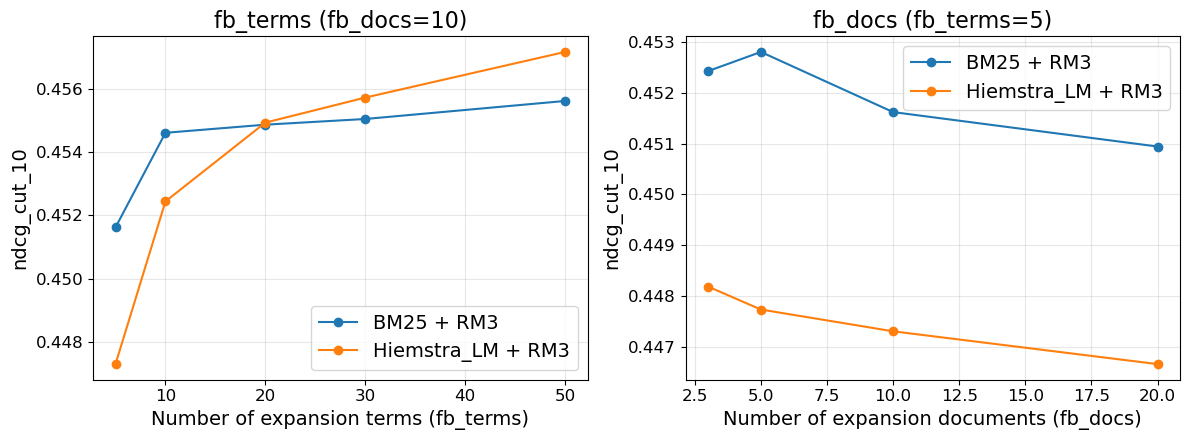

In [ ]:
bm25_rm3_df = pd.DataFrame(rm3_cache["tuning_results"])
lm_rm3_df   = pd.DataFrame(rm3_lm_cache["tuning_results"])

score_col      = f"sample_{EVAL_MEASURE}"   # "sample_ndcg_cut_10"
FIXED_FB_DOCS  = 10
FIXED_FB_TERMS = 5

# Font sizes
title_size = 16
label_size = 14
tick_size  = 12

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# (a) fb_terms sweep at fixed fb_docs
ax = axes[0]
for name, df in [("BM25 + RM3", bm25_rm3_df), ("Hiemstra_LM + RM3", lm_rm3_df)]:
    sub = df[df["fb_docs"] == FIXED_FB_DOCS].sort_values("fb_terms")
    ax.plot(sub["fb_terms"], sub[score_col], marker="o", label=name)
ax.set_xlabel("Number of expansion terms (fb_terms)", fontsize=label_size)
ax.set_ylabel(EVAL_MEASURE, fontsize=label_size)
ax.set_title(f"NDCG@10 vs. expansion terms (feedback documents ={FIXED_FB_DOCS})", fontsize=title_size)
ax.tick_params(axis="both", labelsize=tick_size)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=label_size)

# (b) fb_docs sweep at fixed fb_terms
ax = axes[1]
for name, df in [("BM25 + RM3", bm25_rm3_df), ("Hiemstra_LM + RM3", lm_rm3_df)]:
    sub = df[df["fb_terms"] == FIXED_FB_TERMS].sort_values("fb_docs")
    ax.plot(sub["fb_docs"], sub[score_col], marker="o", label=name)
ax.set_xlabel("Number of expansion documents (fb_docs)", fontsize=label_size)
ax.set_ylabel(EVAL_MEASURE, fontsize=label_size)
ax.set_title(f"fb_docs (fb_terms={FIXED_FB_TERMS})", fontsize=title_size)
ax.tick_params(axis="both", labelsize=tick_size)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=label_size)

plt.tight_layout()
plt.show()